In [1]:
from tensorflow.keras.layers import Dense, Dropout, Flatten, Input, SimpleRNN
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam, SGD

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

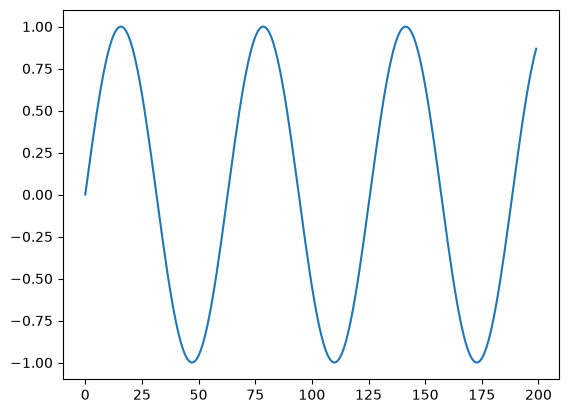

In [ ]:
# Generate synthetic sine wave data
series = np.sin(0.1*np.arange(200)) + np.random.randn(200)*0.1 # sin(w*t) + noise
plt.plot(series)

In [11]:
# Split the dataset into (N,T,D) -> (n_sequences, seq_length, n_features)
T = 10 # seq_length
D = 1 # n_features
X = []
Y = []
for t in range(len(series) - T):
    x = series[t:t+T]
    X.append(x)
    y = series[t+T]
    Y.append(y)

X = np.array(X).reshape(-1, T, 1) # NxTxD
Y = np.array(Y)
N = len(X)
print(f"X shape: {X.shape}, Y shape: {Y.shape}")

X shape: (190, 10, 1), Y shape: (190,)


In [12]:
# Autoregressive RNN model
i = Input(shape=(T,1))
x = SimpleRNN(5, activation=None)(i)
x = Dense(1)(x)

model = Model(i, x)

In [13]:
model.compile(
    loss="mse",
    optimizer=Adam(learning_rate=0.1)
)

r = model.fit(
    X[:-N//2], Y[:-N//2],
    epochs=100,
    validation_data=(X[N//2:], Y[N//2:])
)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step - loss: 1.7883 - val_loss: 0.0695
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0517 - val_loss: 0.0229
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0261 - val_loss: 0.0625
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0457 - val_loss: 0.0266
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0147 - val_loss: 0.0145
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0146 - val_loss: 0.0079
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0053 - val_loss: 0.0043
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0077 - val_loss: 0.0055
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0064 - val_loss: 0.0034
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0029 - val_loss: 0.0046
Epoch 11/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0025 - val_loss: 8.6920e-04
Epoch 12/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0014 - v

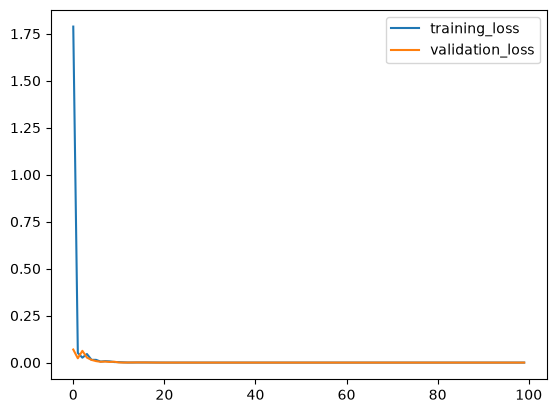

In [14]:
plt.plot(r.history['loss'], label='training_loss')
plt.plot(r.history['val_loss'], label='validation_loss')
plt.legend()

In [15]:
validation_target = Y[N//2:]
validation_prediction = []

last_X = X[-N//2]

while len(validation_prediction) < len(validation_target):
    p = model.predict(last_X.reshape(1, -1, 1))[0,0] 
    validation_prediction.append(p)
    last_X = np.roll(last_X, -1)
    last_X[-1] = p

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━

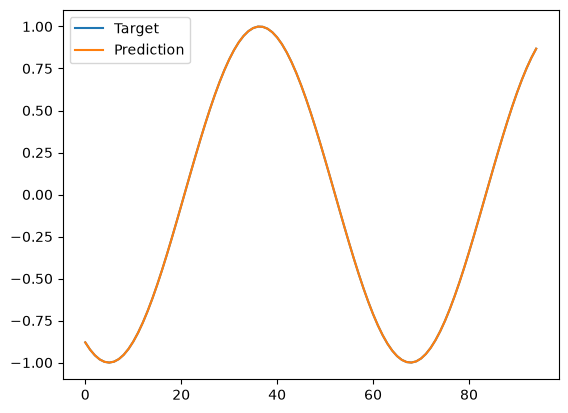

In [16]:
plt.plot(validation_target, label="Target")
plt.plot(validation_prediction, label="Prediction")
plt.legend()